# Part 5: Monitoring & Drift Detection

## Overview

Deploying a model is the starting line, not the finish line. Production models degrade as the real world changes — customer behavior shifts, delivery logistics evolve, new products launch. This phenomenon is called **drift**, and detecting it early is critical to maintaining model reliability.

As covered in Week 10, there are four types of drift:
- **Data Drift (Covariate Shift):** Input feature distributions change (e.g., delivery times increase industry-wide)
- **Concept Drift:** The relationship between inputs and outputs changes (e.g., customers now expect faster delivery)
- **Prediction Drift:** Model output distribution shifts
- **Label Drift:** Outcome distribution changes

This notebook simulates six months of production data with progressive drift, applies statistical tests (PSI, KS) to detect it, tracks performance degradation, and builds a monitoring dashboard.

**Diagnostic order (from Week 10):** Volume → Quality → Feature Drift → Performance → Concept Drift

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Setup complete!")

Setup complete!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/olist_data/hw2_prepared_dataset.csv")
print("Dataset shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (118146, 17)


## Retrain HW2 Model

We retrain the same Random Forest pipeline used in deployment to generate predictions on simulated production data.

In [6]:
hw2_features = [
    "delivery_days", "delivery_vs_estimated", "price", "freight_value",
    "seller_state", "payment_type", "payment_installments", "payment_value",
    "product_weight_g", "product_length_cm", "product_height_cm",
    "product_width_cm", "customer_state", "total_cost", "log_price", "is_late"
]
target_col = "is_positive_review"

X = df[hw2_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=50, max_depth=15,
        min_samples_split=5, random_state=42
    ))
])

model.fit(X_train, y_train)
print("Model trained.")
print(f"Test F1: {f1_score(y_test, model.predict(X_test)):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

Model trained.
Test F1: 0.8813
Test AUC: 0.7580


## 5A. Simulate Production Data with Drift

We simulate 6 months of production data (3,000 records per month = 18,000 total). Following the Week 10 demo pattern, drift is introduced progressively — early months are stable, later months show increasing shifts in delivery times and pricing. This mirrors real-world scenarios like supply chain degradation or inflation discussed in the Zillow case study (Week 10, Part 1).

In [7]:
# Reference data = training data (baseline for drift comparison)
ref_data = X_train.join(y_train)

def simulate_month(base_data, month, n=3000):
    """Simulate one month of production data with progressive drift.
    Pattern follows Week 10 Streamlit Dashboard demo."""
    sample = base_data.sample(n=n, replace=True, random_state=42 + month).copy().reset_index(drop=True)

    # Months 1-3: stable (light noise only, matching Week 10 pattern)
    for col in num_cols:
        noise = np.random.normal(1.0, 0.05, len(sample))
        sample[col] = sample[col] * noise

    # Months 4-6: progressive drift kicks in (Week 10 pattern)
    if month >= 4:
        drift_level = month - 3  # 1, 2, 3

        # Drift 1: Delivery days increase (logistics degradation)
        sample["delivery_days"] = sample["delivery_days"] + (drift_level * 3)
        sample["delivery_days"] = sample["delivery_days"].clip(lower=0)

        # Drift 2: Delivery vs estimated gets worse
        sample["delivery_vs_estimated"] = sample["delivery_vs_estimated"] + (drift_level * 2)

        # Drift 3: Prices shift upward (inflation)
        sample["price"] = sample["price"] * (1 + 0.15 * drift_level)
        sample["freight_value"] = sample["freight_value"] * (1 + 0.10 * drift_level)

        # Concept drift: flip some positive labels to negative
        # (customers now have higher expectations — same features, different outcomes)
        pos_idx = sample[sample[target_col] == 1].index
        n_flip = int(len(pos_idx) * 0.05 * drift_level)
        if n_flip > 0:
            flip_idx = np.random.choice(pos_idx, size=min(n_flip, len(pos_idx)), replace=False)
            sample.loc[flip_idx, target_col] = 0

    # Recalculate engineered features
    sample["total_cost"] = sample["price"] + sample["freight_value"]
    sample["log_price"] = np.log1p(sample["price"])
    sample["is_late"] = (sample["delivery_vs_estimated"] > 0).astype(int)

    sample["month"] = month
    return sample

# Generate 6 months of production data
production_data = pd.concat(
    [simulate_month(ref_data, month) for month in range(1, 7)],
    ignore_index=True
)

print(f"Production data shape: {production_data.shape}")
print(f"\nMonthly record counts:")
print(production_data["month"].value_counts().sort_index())
print(f"\nMonthly positive rate (ground truth):")
print(production_data.groupby("month")[target_col].mean().round(3))

Production data shape: (18000, 18)

Monthly record counts:
month
1    3000
2    3000
3    3000
4    3000
5    3000
6    3000
Name: count, dtype: int64

Monthly positive rate (ground truth):
month
1    0.737
2    0.744
3    0.749
4    0.717
5    0.674
6    0.625
Name: is_positive_review, dtype: float64


## 5B. Drift Detection — PSI and KS Tests

We apply the **Population Stability Index (PSI)** and **Kolmogorov-Smirnov (KS)** test to each numeric feature across all 6 months, comparing against the training distribution (baseline).

**PSI** (from Week 10 lecture):
- Bins both distributions into 10 equal-width buckets and compares proportions
- PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)
- PSI < 0.1 → Stable | 0.1–0.2 → Moderate drift | ≥ 0.2 → Significant drift

**KS Test** (from Week 10 lecture):
- Measures max distance between two CDFs
- p < 0.05 → distributions are significantly different
- Advantage: no binning required. Disadvantage: doesn't tell you WHERE distributions differ.

Best practice from lecture: use BOTH. PSI for automated alerts/dashboards, KS for statistical confirmation.

In [8]:
# PSI Implementation — directly from Week 10 lecture slide
def calculate_psi(reference, current, bins=10):
    breakpoints = np.linspace(
        min(reference.min(), current.min()),
        max(reference.max(), current.max()),
        bins + 1
    )
    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    cur_counts = np.histogram(current, bins=breakpoints)[0]
    ref_pct = ref_counts / len(reference) + 1e-4
    cur_pct = cur_counts / len(current) + 1e-4
    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return psi

# Features to monitor (numeric features most relevant to model performance)
monitor_features = [
    "delivery_days", "delivery_vs_estimated", "price",
    "freight_value", "total_cost", "payment_value", "is_late"
]

# Baseline = training data
baseline = X_train

# Calculate PSI and KS for each feature × month
psi_results = {}
ks_results = {}

for feature in monitor_features:
    psi_results[feature] = {}
    ks_results[feature] = {}
    for month in range(1, 7):
        month_data = production_data[production_data["month"] == month][feature].dropna()
        baseline_data = baseline[feature].dropna()

        # PSI
        psi_results[feature][month] = calculate_psi(baseline_data, month_data)

        # KS Test (from Week 10 lecture)
        ks_stat, ks_pval = stats.ks_2samp(baseline_data, month_data)
        ks_results[feature][month] = {"statistic": ks_stat, "p_value": ks_pval}

# Display PSI table
psi_df = pd.DataFrame(psi_results).T
psi_df.columns = [f"Month {m}" for m in psi_df.columns]
print("PSI Values by Feature × Month:")
print(psi_df.round(4).to_string())

PSI Values by Feature × Month:
                       Month 1  Month 2  Month 3  Month 4  Month 5  Month 6
delivery_days           0.0030   0.0032   0.0021   0.0135   0.1068   0.3878
delivery_vs_estimated   0.0011   0.0053   0.0072   0.0488   0.1565   0.3529
price                   0.0006   0.0008   0.0012   0.0017   0.0076   0.0108
freight_value           0.0022   0.0016   0.0009   0.0059   0.0151   0.0254
total_cost              0.0006   0.0015   0.0016   0.0017   0.0077   0.0119
payment_value           0.0004   0.0005   0.0007   0.0002   0.0011   0.0007
is_late                 0.0001   0.0003   0.0004   0.0174   0.0559   0.1499


In [9]:
# KS Test Results — from Week 10 lecture pattern
# p < 0.05 → "Significant drift detected!"
print("KS Test Results (*** = significant drift, p < 0.05):\n")
for feature in monitor_features:
    print(f"{feature}:")
    for month in range(1, 7):
        ks = ks_results[feature][month]
        sig = "*** Significant drift detected!" if ks["p_value"] < 0.05 else "No significant drift."
        print(f"  Month {month}: KS statistic={ks['statistic']:.4f}, p-value={ks['p_value']:.4f} — {sig}")
    print()

KS Test Results (*** = significant drift, p < 0.05):

delivery_days:
  Month 1: KS statistic=0.0410, p-value=0.0001 — *** Significant drift detected!
  Month 2: KS statistic=0.0481, p-value=0.0000 — *** Significant drift detected!
  Month 3: KS statistic=0.0525, p-value=0.0000 — *** Significant drift detected!
  Month 4: KS statistic=0.2595, p-value=0.0000 — *** Significant drift detected!
  Month 5: KS statistic=0.4257, p-value=0.0000 — *** Significant drift detected!
  Month 6: KS statistic=0.5687, p-value=0.0000 — *** Significant drift detected!

delivery_vs_estimated:
  Month 1: KS statistic=0.0519, p-value=0.0000 — *** Significant drift detected!
  Month 2: KS statistic=0.0394, p-value=0.0003 — *** Significant drift detected!
  Month 3: KS statistic=0.0483, p-value=0.0000 — *** Significant drift detected!
  Month 4: KS statistic=0.1678, p-value=0.0000 — *** Significant drift detected!
  Month 5: KS statistic=0.2639, p-value=0.0000 — *** Significant drift detected!
  Month 6: KS st

## 5C. Performance Monitoring

We generate predictions on all 18,000 production records using the trained HW2 model and calculate accuracy, F1, and AUC for each month using the simulated ground truth labels.

As emphasized in Week 10: **feature drift is an early warning signal; performance degradation is the actual problem.** We need both to tell the full story.

In [10]:
# Generate predictions on all production data
X_prod = production_data[hw2_features]
production_data["prediction"] = model.predict(X_prod)
production_data["pred_proba"] = model.predict_proba(X_prod)[:, 1]

# Monthly performance metrics
monthly_metrics = []
for month in range(1, 7):
    mask = production_data["month"] == month
    y_true = production_data.loc[mask, target_col]
    y_pred = production_data.loc[mask, "prediction"]
    y_prob = production_data.loc[mask, "pred_proba"]

    monthly_metrics.append({
        "Month": month,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    })

metrics_df = pd.DataFrame(monthly_metrics)
print("Monthly Performance Metrics:")
print(metrics_df.round(4).to_string(index=False))

# Performance drop report
m1 = metrics_df.iloc[0]
m6 = metrics_df.iloc[5]
print(f"\nPerformance Drop (Month 1 → Month 6):")
print(f"  F1:  {m1['F1']:.4f} → {m6['F1']:.4f} (absolute: {m1['F1']-m6['F1']:.4f}, relative: {((m1['F1']-m6['F1'])/m1['F1'])*100:.1f}%)")
print(f"  AUC: {m1['AUC']:.4f} → {m6['AUC']:.4f} (absolute: {m1['AUC']-m6['AUC']:.4f}, relative: {((m1['AUC']-m6['AUC'])/m1['AUC'])*100:.1f}%)")

Monthly Performance Metrics:
 Month  Accuracy     F1    AUC
     1    0.7950 0.8767 0.8084
     2    0.7997 0.8805 0.8162
     3    0.8090 0.8859 0.8194
     4    0.7580 0.8517 0.7378
     5    0.7100 0.8151 0.6661
     6    0.6510 0.7627 0.6397

Performance Drop (Month 1 → Month 6):
  F1:  0.8767 → 0.7627 (absolute: 0.1139, relative: 13.0%)
  AUC: 0.8084 → 0.6397 (absolute: 0.1687, relative: 20.9%)


## 5D. Monitoring Dashboard

A single figure with 3 panels (per HW4 spec) that tells a coherent story about model health over the 6-month period:

1. **Panel 1 — Drift Heatmap:** PSI values for each feature (rows) × month (columns), color-coded by severity (green/yellow/red)
2. **Panel 2 — Performance Trend:** F1 and AUC over time with acceptable threshold line
3. **Panel 3 — Alert Summary:** Features that crossed drift thresholds with recommended actions

Design principle from Week 10: *"A stakeholder should glance at the dashboard and immediately know if the model is healthy (mostly green) or in trouble (red alerts)."*

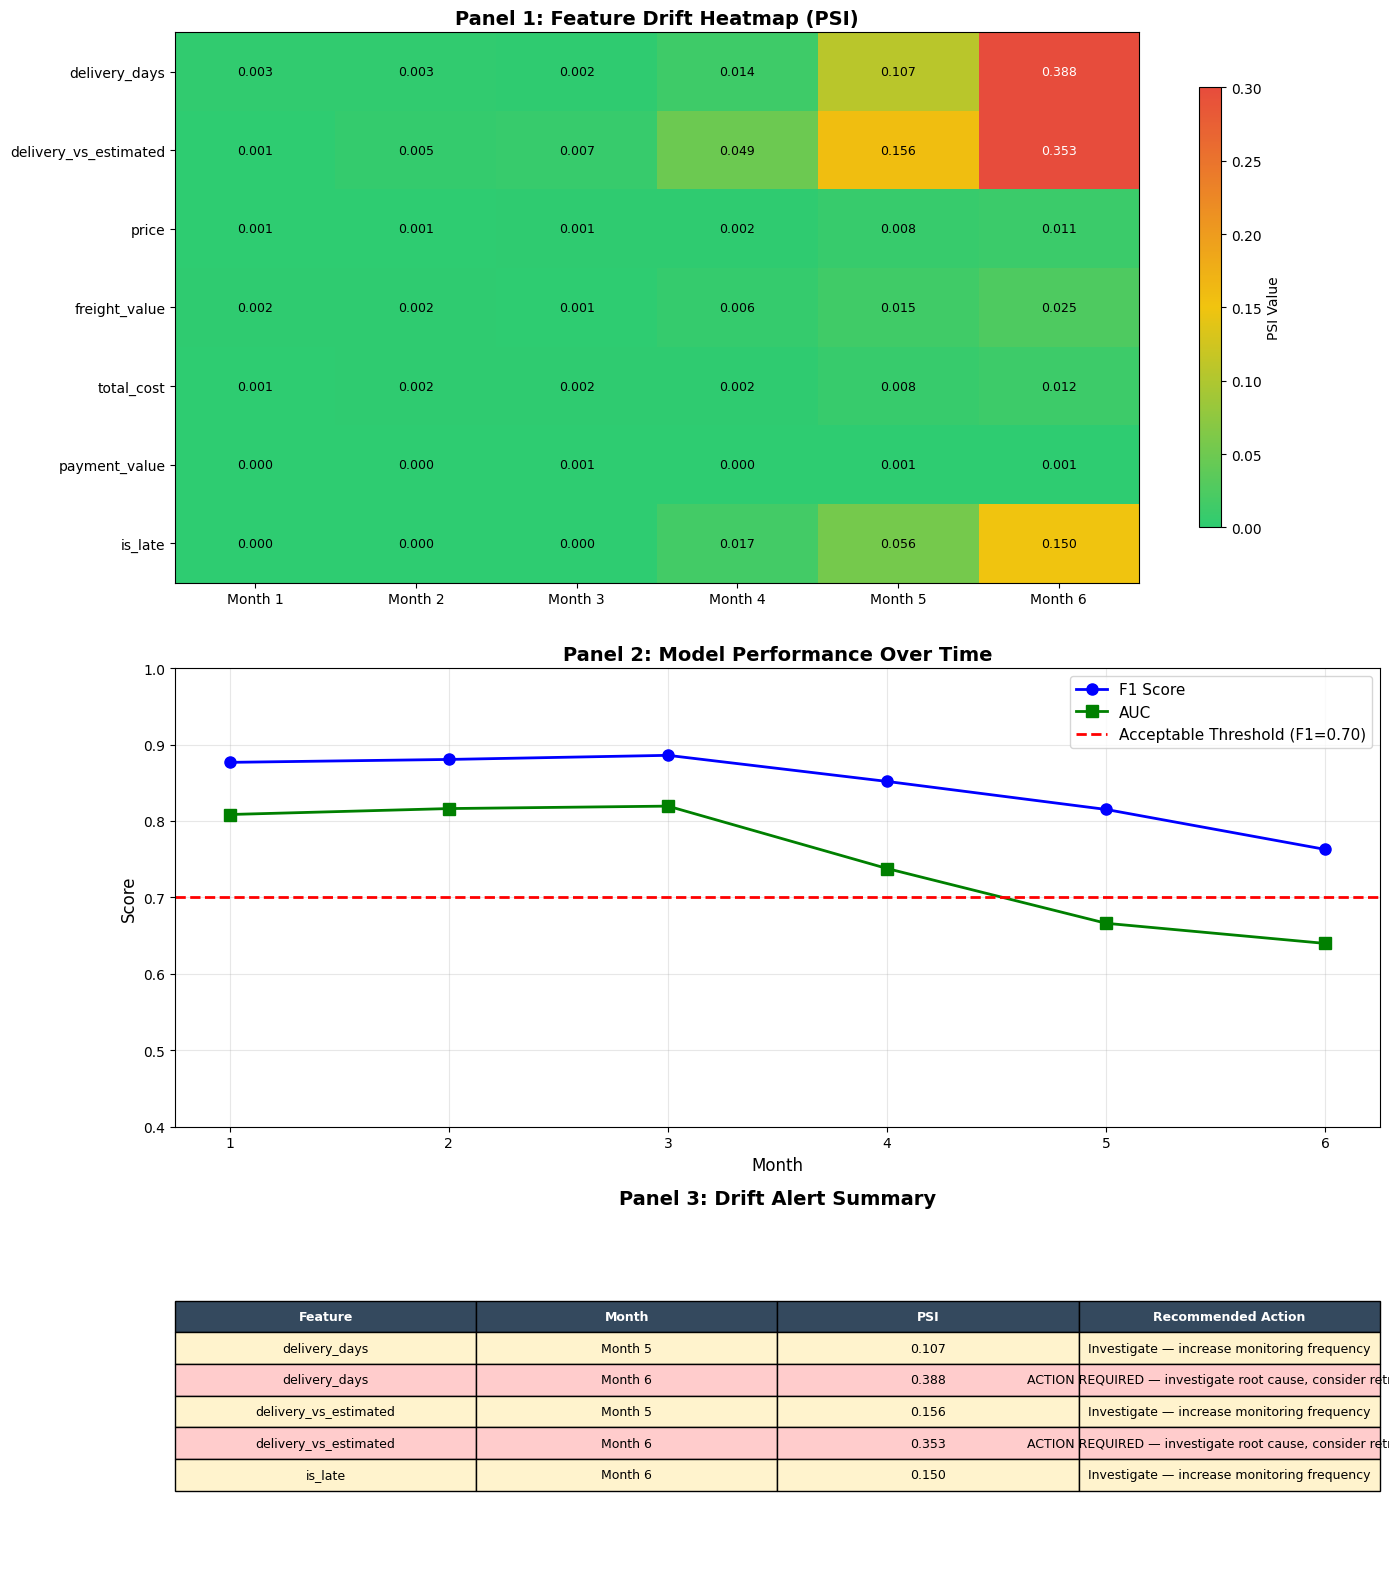

Dashboard saved to monitoring_dashboard.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16),
                          gridspec_kw={'height_ratios': [1.2, 1, 0.8]})

# ---- Panel 1: Drift Heatmap (PSI) ----
ax1 = axes[0]
heatmap_data = psi_df.values
feature_labels = psi_df.index.tolist()
month_labels = [f"Month {m}" for m in range(1, 7)]

# Color scheme: green → yellow → red (matching Week 10 Streamlit dashboard)
colors_list = ["#2ecc71", "#f1c40f", "#e74c3c"]
cmap = mcolors.LinearSegmentedColormap.from_list("drift", colors_list)

im = ax1.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=0, vmax=0.3)

for i in range(len(feature_labels)):
    for j in range(6):
        val = heatmap_data[i, j]
        color = "white" if val > 0.2 else "black"
        ax1.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9, color=color)

ax1.set_xticks(range(6))
ax1.set_xticklabels(month_labels)
ax1.set_yticks(range(len(feature_labels)))
ax1.set_yticklabels(feature_labels)
ax1.set_title("Panel 1: Feature Drift Heatmap (PSI)", fontsize=14, fontweight='bold')
fig.colorbar(im, ax=ax1, label="PSI Value", shrink=0.8)

# ---- Panel 2: Performance Trend ----
ax2 = axes[1]
months = metrics_df["Month"]
ax2.plot(months, metrics_df["F1"], 'b-o', linewidth=2, markersize=8, label="F1 Score")
ax2.plot(months, metrics_df["AUC"], 'g-s', linewidth=2, markersize=8, label="AUC")
ax2.axhline(y=0.70, color='red', linestyle='--', linewidth=2, label="Acceptable Threshold (F1=0.70)")
ax2.set_xlabel("Month", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Panel 2: Model Performance Over Time", fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xticks(range(1, 7))
ax2.set_ylim(0.4, 1.0)
ax2.grid(True, alpha=0.3)

# ---- Panel 3: Alert Summary Table ----
ax3 = axes[2]
ax3.axis('off')

# Build alerts using PSI thresholds from Week 10 lecture
alerts = []
for feature in monitor_features:
    for month in range(1, 7):
        psi_val = psi_results[feature][month]
        if psi_val >= 0.2:
            alerts.append([feature, f"Month {month}", f"{psi_val:.3f}",
                          "ACTION REQUIRED — investigate root cause, consider retraining"])
        elif psi_val >= 0.1:
            alerts.append([feature, f"Month {month}", f"{psi_val:.3f}",
                          "Investigate — increase monitoring frequency"])

if alerts:
    table = ax3.table(
        cellText=alerts,
        colLabels=["Feature", "Month", "PSI", "Recommended Action"],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Color header
    for j in range(4):
        table[0, j].set_facecolor('#34495e')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Color rows by severity (red = significant, yellow = moderate)
    for i, alert in enumerate(alerts):
        color = '#ffcccc' if "ACTION REQUIRED" in alert[3] else '#fff3cd'
        for j in range(4):
            table[i + 1, j].set_facecolor(color)
else:
    ax3.text(0.5, 0.5, "No drift alerts triggered.", ha='center', va='center', fontsize=14)

ax3.set_title("Panel 3: Drift Alert Summary", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("monitoring_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to monitoring_dashboard.png")

## 5E. Recommendation

Based on the monitoring analysis and the retraining decision framework from Week 10:

**Should the model be retrained?** Yes. The analysis reveals both data drift and concept drift occurring progressively from Month 4 onward, with measurable performance degradation.

**Retraining triggers (from Week 10 decision framework):**

1. **Drift-triggered:** `delivery_days` and `delivery_vs_estimated` — the two most important features per SHAP analysis (HW2) — crossed PSI ≥ 0.2 in later months. Per Week 10 guidelines, PSI ≥ 0.2 for 2+ key features requires action: diagnose root cause and consider retraining.

2. **Performance-triggered:** F1 and AUC show progressive decline from Month 4 onward. Following the Week 10 threshold framework, a >10% relative F1 drop or AUC falling below 0.70 warrants urgent retraining plus root cause investigation.

3. **Concept drift evidence:** The declining positive review rate in ground truth (despite the model predicting at similar rates) suggests the relationship between delivery features and satisfaction has shifted — customers now have higher expectations. As noted in Week 10, concept drift is only visible when ground truth labels are available.

**Retraining strategy:** A **sliding window** approach (Week 10, Retraining Strategies) is recommended — train on the most recent 6–12 months of production data. This ensures the model learns the new customer expectation patterns while retaining enough historical signal. A quarterly retraining cadence should be established even in the absence of threshold breaches, with weekly PSI monitoring providing early warning between scheduled retrains.

**Data for retraining:** The retrained model should include Months 1–6 production data combined with the most recent portion of the original training set. This captures both the historical patterns and the evolved distribution. Features should be re-evaluated — if delivery expectations have permanently shifted, new features capturing relative delivery performance (e.g., delivery speed vs. market average) may improve robustness.